#Task - 1: Implementation of MCP Neurons:

###For ”AND” Operations.

In [1]:
import numpy as np

def MCP_Neurons_AND(X1, X2, T):
    """
    This function implements basic AND operations with MCP Neuron for two inputs.
    """
    assert len(X1) == len(X2)

    # Perform an element-wise addition of two input arrays stored in a new array (list)
    # This simulates the "Aggregation" of inputs in an MCP neuron
    input_sum = np.array(X1) + np.array(X2)

    # Create a new array to put all the predictions
    state_neuron = []

    # Append 1 if sum is above or equal to Threshold else append 0
    for val in input_sum:
        if val >= T:
            state_neuron.append(1)
        else:
            state_neuron.append(0)

    return state_neuron

###Sample Usage for ”AND” Function.

In [2]:
# Sample Usage for "AND" Function
X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
T = 2  # Threshold value (Both inputs must be 1 to reach a sum of 2)

result = MCP_Neurons_AND(X1, X2, T)
print(f"Output of AND gate for inputs {X1} and {X2} with threshold {T}: {result}")

Output of AND gate for inputs [0, 0, 1, 1] and [0, 1, 0, 1] with threshold 2: [0, 0, 0, 1]


###For ”OR” Operations.

In [4]:
def MCP_Neurons_OR(X1, X2, T):
    """
    This function implements basic OR operations with MCP Neuron for two inputs.
    """
    assert len(X1) == len(X2)

    # Perform an element-wise addition
    input_sum = np.array(X1) + np.array(X2)

    # Create the prediction list
    state_neuron = []

    # Append 1 if sum is >= Threshold (1) else append 0
    # In OR, if any input is 1, the sum is >= 1
    for val in input_sum:
        if val >= T:
            state_neuron.append(1)
        else:
            state_neuron.append(0)

    return state_neuron


###Sample Usage for ”OR” Function.

In [5]:
# Sample Usage for "OR" Function
X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
T = 1  # Threshold value (Any input being 1 reaches a sum of 1)

result_or = MCP_Neurons_OR(X1, X2, T)
print(f"Output of OR gate for inputs {X1} and {X2} with threshold {T}: {result_or}")

Output of OR gate for inputs [0, 0, 1, 1] and [0, 1, 0, 1] with threshold 1: [0, 1, 1, 1]


###Question - 1: List out all the limitations of MCP - Neurons.

* The weights and thresholds must be manually set by a human for each specific logic task, as the system cannot learn from data.

* It only supports binary inputs (0 or 1) and produces binary outputs.

* All excitatory weights are generally the same, which prevents the model from assigning varying levels of importance to different inputs.

* With a single unit and fixed threshold, it can only handle linearly separable problems and therefore cannot solve more complex functions like XOR.

* The activation is based on a rigid threshold, offering no gradual or nuanced output, which limits its ability to handle complex decision-making.


####Question -2: XOR Logic Using MCP NeuronsAs you noted in your paragraph, solving XOR requires a multi-step logic because a single neuron cannot handle the "exclusive" part of the gate.

In [6]:
from google.colab import drive
drive.mount('/content/drive')
%cd /content/drive/MyDrive/AI-ML/Worksheet3

Mounted at /content/drive
/content/drive/MyDrive/AI-ML/Worksheet3


In [9]:
import pandas as pd
import numpy as np
# Load the dataset
df_0_1 = pd.read_csv("mnist_0_and_1.csv")
# Extract features and labels
X = df_0_1.drop(columns=["label"]).values # 784 pixels
y = df_0_1["label"].values # Labels (0 or 1)
# Check the shape of the features and labels
print("Feature matrix shape:", X.shape)
print("Label vector shape:", y.shape)


Feature matrix shape: (12665, 784)
Label vector shape: (12665,)


####Question - 1: What does the shape of X represent?


The shape of ( X ) represents the structure of the dataset, where the rows (( n )) correspond to the total number of images, and the columns (784) represent the features of each image. Since each MNIST image has a size of ( 28 \times 28 ) pixels, it is flattened into a one-dimensional vector containing 784 pixel values, where each value indicates the intensity of a particular pixel.


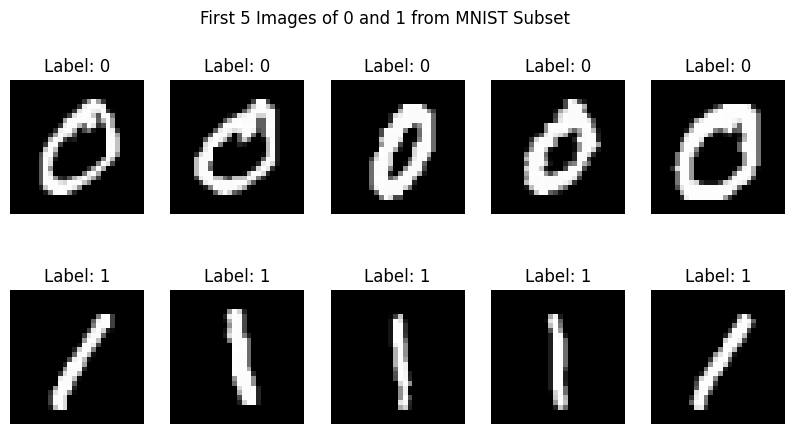

In [10]:
#Visuaizing dataset

import matplotlib.pyplot as plt

images_0 = X[y == 0] # Get all images with label 0
images_1 = X[y == 1] # Get all images with label 1
fig, axes = plt.subplots(2, 5, figsize=(10, 5))
# Check if the arrays have the required amount of data
if len(images_0) < 5 or len(images_1) < 5:
  print("Error: Not enough images in images_0 or images_1 to plot 5 images.")
else:
  for i in range(5):
# Plot digit 0
    axes[0, i].imshow(images_0[i].reshape(28, 28), cmap="gray")
    axes[0, i].set_title("Label: 0")
    axes[0, i].axis("off")
# Plot digit 1
    axes[1, i].imshow(images_1[i].reshape(28, 28), cmap="gray")
    axes[1, i].set_title("Label: 1")
    axes[1, i].axis("off")
  plt.suptitle("First 5 Images of 0 and 1 from MNIST Subset")
  plt.show()

In [12]:
# Initialize weights and bias
weights = np.zeros(X.shape[1])
bias = 0
learning_rate = 0.1
epochs = 100

####Question -3: What does the weights array represent in this context?

The weights indicate how important each pixel is in deciding whether an image represents a 0 or a 1. A positive weight means that when a particular pixel is active, it increases the likelihood that the image is a 1, whereas a negative weight suggests that the pixel being active makes it more likely to be a 0.


####Question 4: Why are we initializing the weights to zero? What effect could this have?

Initializing the weights to zero gives a neutral starting point for the model. Unlike deep neural networks, where zero initialization can lead to symmetry issues, a single perceptron can handle it without problems. However, the initial prediction will depend only on the bias, and the model will rely on the first few training examples to begin adjusting the weights away from zero.


In [13]:
#Implement a Decision Function or Activation Function:

import numpy as np
def decision_function(X, weights, bias):
  """
Compute the predicted labels for the input data.
Parameters:
- X: Features (input data) as a numpy array of shape (n_samples, n_features)
- weights: Updated weights after training
- bias: Updated bias after training
Returns:
- y_pred_all: The predicted labels for the input data """
  predictions = np.dot(X, weights) + bias
  y_pred_all = np.where(predictions >= 0,1,0)
  return y_pred_all

In [14]:
import numpy as np

def train_perceptron(X, y, weights, bias, learning_rate=0.1, epochs=100):
    # Step 3: Perceptron Learning Algorithm
    for epoch in range(epochs):
        for i in range(len(X)):
            # 1. Linear output (Weighted sum + bias)
            linear_output = np.dot(X[i], weights) + bias

            # 2. Step function (Guess 1 or 0)
            y_pred = 1 if linear_output >= 0 else 0

            # 3. Update weights and bias ONLY if the prediction was wrong
            if y[i] != y_pred:
                error = y[i] - y_pred
                weights = weights + learning_rate * error * X[i]
                bias = bias + learning_rate * error

    # --- IMPORTANT: These lines must be outside the loops ---
    # After all epochs are done, calculate the final accuracy
    y_pred_all = decision_function(X, weights, bias)
    accuracy = np.mean(y_pred_all == y)

    return weights, bias, accuracy

####Question 5. What is the purpose of output = np.dot(X[i], weights) + bias?

The expression `output = np.dot(X[i], weights) + bias` is used to compute the linear combination of inputs and weights. It works by multiplying each input feature with its corresponding weight and summing the results, then adding the bias term to shift the decision boundary.


####Question6. What happens when the prediction is wrong?

When the prediction is wrong, the model updates weights and bias to reduce error using the formula:\
weights = weights + learning_rate * (y[i] - y_pred) * X[i]\
bias = bias + learning_rate * (y[i] - y_pred)

####Question7. Why is final accuracy important? What do you expect it to be?

Final accuracy is important because it indicates how well the model has learned and serves as a measure of its overall performance. For simple logic gates like OR and AND, the expected accuracy is 1 (perfect), since they are linearly separable problems. However, for XOR, a single perceptron cannot achieve perfect accuracy because the problem is not linearly separable.


In [15]:
#After training model with perceptron learning algorithm
weights, bias, accuracy = train_perceptron(X, y, weights, bias)
print("The final Accuracy is: ", accuracy)

The final Accuracy is:  1.0


In [16]:
# Get predictions for all data points
predictions = np.dot(X, weights) + bias
y_pred = np.where(predictions >= 0, 1, 0)
# Calculate final accuracy
final_accuracy = np.mean(y_pred == y)
print(f"Final Accuracy: {final_accuracy:.4f}")
# Step 5: Visualize Misclassified Images
misclassified_idx = np.where(y_pred != y)[0]
if len(misclassified_idx) > 0:
    fig, axes = plt.subplots(2, 5, figsize=(10, 5))
    for ax, idx in zip(axes.flat, misclassified_idx[:10]): # Show 10 misclassified images
      ax.imshow(X[idx].reshape(28, 28), cmap="gray")
      ax.set_title(f"Pred: {y_pred[idx]}, True: {y[idx]}")
      ax.axis("off")
    plt.suptitle("Misclassified Images")
    plt.show()
else:
    print("All images were correctly classified!")


Final Accuracy: 1.0000
All images were correctly classified!


####Question8. What does misclassified_idx store, and how is it used in this code?

It stores the indices of all incorrectly predicted samples. In the code, the condition `if len(misclassified_idx) > 0:` checks whether there are any misclassified examples. Then, the loop `for ax, idx in zip(axes.flat, misclassified_idx[:10]):` selects the first 10 misclassified samples, where `idx` represents the index of each incorrect image and `ax` refers to the subplot used for displaying it. The line `ax.imshow(X[idx].reshape(28, 28), cmap="gray")` uses the index to retrieve the misclassified image from the dataset and reshapes it into a 28×28 format for visualization in grayscale. Finally, `ax.set_title(f"Pred: {y_pred[idx]}, True: {y[idx]}")` displays the predicted label alongside the actual label for comparison.


####Question9. How do you interepret the reuslt if output is "All images were correctly classified?"

If the output displays “All images were correctly classified!”, it means that the perceptron model made no prediction errors on the dataset. This indicates that the model has successfully learned a suitable decision boundary to distinguish between the two classes (digits 3 and 5). Such a result usually implies that the data is linearly separable and that the perceptron was able to classify it perfectly.


##Task 3

In [17]:
#Task 3: Perceptron Algorithm for 3 vs 5 Classification.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#mount
from google.colab import drive
drive.mount('/content/drive')
%cd /content/drive/MyDrive/AI-ML/Worksheet3

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/AI-ML/Worksheet3


In [18]:
#Loading datatset
df = pd.read_csv("mnist_3_and_5.csv")

In [19]:
#Seperate feature and label
X = df.drop(columns=["label"]).values
y = df["label"].values

X = X / 255.0
print("Feature matrix shape:", X.shape)
print("Label vector shape:", y.shape)

Feature matrix shape: (2741, 784)
Label vector shape: (2741,)


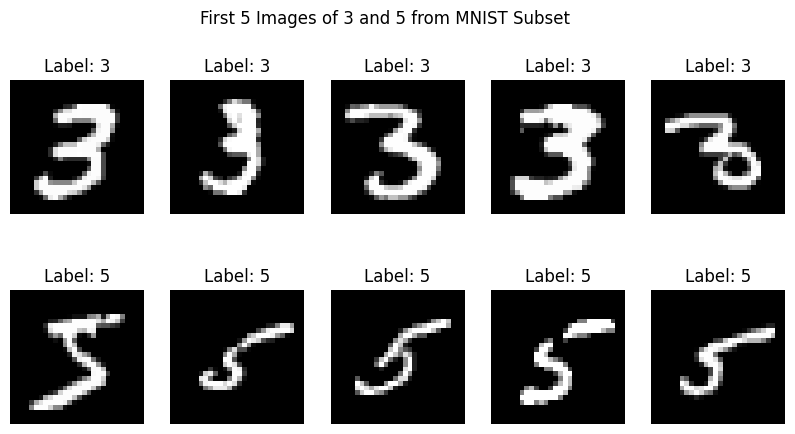

In [20]:
# Step 2: Visualize first few images
images_3 = X[y == 3]
images_5 = X[y == 5]

fig, axes = plt.subplots(2, 5, figsize=(10, 5))
# Check if the arrays have the required amount of data
if len(images_3) < 5 or len(images_5) < 5:
  print("Error: Not enough images in images_0 or images_1 to plot 5 images.")
else:
  for i in range(5):
    axes[0, i].imshow(images_3[i].reshape(28, 28), cmap="gray")
    axes[0, i].set_title("Label: 3")
    axes[0, i].axis("off")

    axes[1, i].imshow(images_5[i].reshape(28, 28), cmap="gray")
    axes[1, i].set_title("Label: 5")
    axes[1, i].axis("off")
plt.suptitle("First 5 Images of 3 and 5 from MNIST Subset")
plt.show()

In [21]:
# --- Step 4: Decision function ---
def decision_function(X, weights, bias):
    # Compute the weighted sum for all samples
    predictions = np.dot(X, weights) + bias
    # If score >= 0, predict 1 (Digit 5), else 0 (Digit 3)
    y_pred_all = np.where(predictions >= 0, 1, 0)
    return y_pred_all

# --- Step 5: Train Perceptron Function ---
def train_perceptron(X, y, weights, bias, learning_rate=0.1, epochs=100):
    y_binary = np.where(y == 5, 1, 0)
    n_samples = len(X)

    for epoch in range(epochs):
        errors_in_epoch = 0

        for i in range(n_samples):
            # Compute weighted sum (z)
            linear_output = np.dot(X[i], weights) + bias
            # Prediction (y_hat)
            y_pred = 1 if linear_output >= 0 else 0

            # Update weights
            if y_pred != y_binary[i]:
                error = y_binary[i] - y_pred
                weights += learning_rate * error * X[i]
                bias += learning_rate * error

                errors_in_epoch += 1

        # Calculate accuracy for the current epoch
        accuracy = 1 - (errors_in_epoch / n_samples)
        if errors_in_epoch == 0:
            print(f"Converged early at epoch {epoch}")
            break

    return weights, bias, accuracy

In [22]:
# --- Step 6: Execute Training ---
# After training, accuracy will reflect the performance of the final epoch
weights, bias, final_accuracy = train_perceptron(X, y, weights, bias, learning_rate, epochs)
print(f"The Final Training Accuracy is: {final_accuracy:.4f}")

The Final Training Accuracy is: 0.9475


Final Accuracy: 0.9497


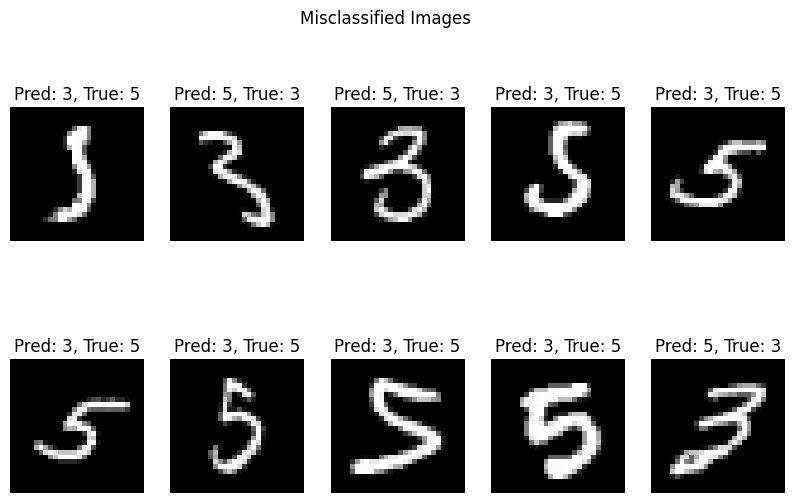

In [23]:
# --- Step 6: Final Evaluation ---

# Getting raw scores (z = W.X + b)
predictions_raw = np.dot(X, weights) + bias

# Converting raw scores to binary predictions (0 or 1)
y_pred_binary = np.where(predictions_raw >= 0, 1, 0)

# Creating a binary version of the ground truth for comparison
# We assume 5 is the 'positive' class (1) and 3 is 'negative' (0)
y_binary = np.where(y == 5, 1, 0)

# Calculating final accuracy
final_accuracy = np.mean(y_pred_binary == y_binary)
print(f"Final Accuracy: {final_accuracy:.4f}")

#Step 7: Visualize Misclassified Images

# Find the indices where the binary prediction doesn't match the binary truth
misclassified_idx = np.where(y_pred_binary != y_binary)[0]

if len(misclassified_idx) > 0:
    fig, axes = plt.subplots(2, 5, figsize=(10, 6))
    # Map the binary predictions back to human-readable digits (3 and 5)
    # If prediction was 1, it's a 5. If it was 0, it's a 3.
    y_pred_digits = np.where(y_pred_binary == 1, 5, 3)
    #Show 10 misclasiified images
    for ax, idx in zip(axes.flat, misclassified_idx[:10]):
        # Show the image (reshape 784 back to 28x28)
        ax.imshow(X[idx].reshape(28, 28), cmap="gray")

        # Display the actual digit values (3 and 5) so the viva looks professional
        ax.set_title(f"Pred: {y_pred_digits[idx]}, True: {y[idx]}")
        ax.axis("off")

    plt.suptitle("Misclassified Images")
    plt.show()
else:
    print("All images were correctly identified.")